# 1 - Transformações — reduzir assimetria antes da GAIN

## Objetivo

Aplicar as **transformações** recomendadas em `Code/2 - EDA/02_distribuicoes.ipynb` (Box-Cox e Yeo-Johnson) para deixar as variáveis numéricas próximas da simetria, num formato amigável para o gradiente da GAIN. **Reutilizamos** os λ já computados via MLE na Etapa 1 (persistidos em `dist_resumo.csv`) em vez de reestimar — garante consistência entre treino e validação e evita variação numérica.

## Posição na Etapa 2

Notebook **1 de 6** do pré-processamento. Entrega `dataset_transformado.parquet` e `transform_params.json`. Consumido por `02_features_temporais.ipynb`.

## Decisões (recapituladas de `Code/2 - EDA/resumo.md`)

| Tratamento | Variáveis | Justificativa |
|---|---|---|
| **Identidade** | pH, Temperatura da Água, Microcistinas | `|skew| < 1`; não há ganho em transformar. Microcistinas tem `n=52` (transformação pouco confiável). |
| **Yeo-Johnson** | DBO, OD, Nitrogênio Amoniacal Total | Variáveis com **zeros**; Box-Cox exige `x > 0`. |
| **Box-Cox** | Nitrato, Fósforo Total, Condutividade, Turbidez, Sólidos Suspensos Totais, Coliformes Termotolerantes, Cianobactérias | Estritamente positivas e assimétricas (|skew| ≥ 1). |

### Alerta propagado para a Etapa 4

**Fósforo Total** mantém kurtosis residual = 8,9 mesmo após Box-Cox (λ ≈ −0,13). São eventos extremos genuínos de eutrofização, não outliers a suprimir. Registrado em `transform_params.json` como `alerta: kurtosis_residual_alta` — `04_GAIN/03_diagnostico.ipynb` deve verificar explicitamente a cobertura da cauda superior dessa variável no gerador.

## Setup

Imports + caminhos relativos a este notebook (`Code/3 - Preprocessing/01_transformacoes.ipynb`).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, special

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
DIST_RESUMO = Path("../../Data/Figures/01_EDA/tabelas/dist_resumo.csv")
OUT_DIR     = Path("../../Data/ProcessedData")
FIG_DIR     = Path("../../Data/Figures/02_Preprocessing/figuras")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

REVERSIBILIDADE_TOL = 1e-6

## Carregamento

Lê o dataset consolidado e as decisões/parâmetros persistidos na Etapa 1.

In [2]:
df = pd.read_excel(DATA_PATH)
print(f"Shape do dataset: {df.shape}")

tab_dist = pd.read_csv(DIST_RESUMO, encoding="utf-8")
# Constrói o dicionário transformacoes a partir do CSV — { variavel: (tipo, lambda) }
transformacoes = {
    row["variavel"]: (row["transformacao_sugerida"],
                       float(row["lambda_boxcox"]) if pd.notna(row["lambda_boxcox"]) else None)
    for _, row in tab_dist.iterrows()
}

# Sanidade: todas as 13 variáveis estão cobertas pelo dist_resumo
faltando = [v for v in VARS if v not in transformacoes]
assert not faltando, f"Variáveis sem entrada no dist_resumo.csv: {faltando}"

pd.DataFrame([
    {"variavel": v, "tipo": transformacoes[v][0], "lambda": transformacoes[v][1]}
    for v in VARS
])

Shape do dataset: (657, 30)


,variavel,tipo,lambda
0,DBO,yeo-johnson,0.07826
1,OD,yeo-johnson,0.28240
2,Nitrato,boxcox,-0.39350
3,Nitrogênio Amoniacal Total,yeo-johnson,-0.07845
4,Fósforo Total,boxcox,-0.13460
5,Condutividade,boxcox,0.38180
6,pH,identidade,NaN
7,Turbidez,boxcox,0.02785
8,Temperatura da Água,identidade,NaN
9,Sólidos Suspensos Totais,boxcox,0.29110


## Funções de transformação

Cada par `(apply_*, invert_*)` é determinístico e preserva NaN. A inversão é a peça crítica: na Etapa 6 (`06_PostImputation`) precisamos voltar à escala original antes de calcular IQA ou comparar com baselines.

**Box-Cox** (exige `x > 0`):

- `λ ≠ 0`: `y = (x^λ − 1) / λ`; inversa: `x = (λ·y + 1)^(1/λ)`.
- `λ = 0`: `y = ln(x)`; inversa: `x = exp(y)`.

**Yeo-Johnson** (aceita zeros/negativos — cobertura piecewise):

- `x ≥ 0, λ ≠ 0`: `y = ((x+1)^λ − 1) / λ`
- `x ≥ 0, λ = 0`: `y = ln(x+1)`
- `x < 0, λ ≠ 2`: `y = −((−x+1)^(2−λ) − 1) / (2−λ)`
- `x < 0, λ = 2`: `y = −ln(−x+1)`

In [3]:
def apply_boxcox(x: np.ndarray, lmbda: float) -> np.ndarray:
    """Box-Cox com λ fixo (já estimado na Etapa 1). NaN são preservados."""
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan)
    mask = ~np.isnan(x)
    if not mask.any():
        return y
    assert (x[mask] > 0).all(), "Box-Cox exige x > 0; encontrei valores não-positivos."
    y[mask] = special.boxcox(x[mask], lmbda)
    return y


def invert_boxcox(y: np.ndarray, lmbda: float) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    x = np.full_like(y, np.nan)
    mask = ~np.isnan(y)
    x[mask] = special.inv_boxcox(y[mask], lmbda)
    return x


def apply_yeojohnson(x: np.ndarray, lmbda: float) -> np.ndarray:
    """Yeo-Johnson com λ fixo. NaN preservados."""
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan)
    mask = ~np.isnan(x)
    if not mask.any():
        return y
    y[mask] = stats.yeojohnson(x[mask], lmbda=lmbda)
    return y


def invert_yeojohnson(y: np.ndarray, lmbda: float) -> np.ndarray:
    """Inversão analítica de Yeo-Johnson (não há helper direto no SciPy)."""
    y = np.asarray(y, dtype=float)
    x = np.full_like(y, np.nan)
    mask = ~np.isnan(y)
    if not mask.any():
        return x

    ym = y[mask]
    xm = np.empty_like(ym)
    pos = ym >= 0
    neg = ~pos

    # Ramo positivo
    if np.isclose(lmbda, 0.0):
        xm[pos] = np.expm1(ym[pos])
    else:
        xm[pos] = np.power(ym[pos] * lmbda + 1.0, 1.0 / lmbda) - 1.0

    # Ramo negativo
    if np.isclose(lmbda, 2.0):
        xm[neg] = 1.0 - np.exp(-ym[neg])
    else:
        expo = 2.0 - lmbda
        xm[neg] = 1.0 - np.power(-expo * ym[neg] + 1.0, 1.0 / expo)

    x[mask] = xm
    return x


def aplicar_transformacao(x: np.ndarray, tipo: str, lmbda):
    if tipo == "identidade":
        return np.asarray(x, dtype=float).copy()
    if tipo == "boxcox":
        return apply_boxcox(x, lmbda)
    if tipo == "yeo-johnson":
        return apply_yeojohnson(x, lmbda)
    raise ValueError(f"Tipo desconhecido: {tipo!r}")


def inverter_transformacao(y: np.ndarray, tipo: str, lmbda):
    if tipo == "identidade":
        return np.asarray(y, dtype=float).copy()
    if tipo == "boxcox":
        return invert_boxcox(y, lmbda)
    if tipo == "yeo-johnson":
        return invert_yeojohnson(y, lmbda)
    raise ValueError(f"Tipo desconhecido: {tipo!r}")

## Aplicação variável-a-variável

Loop pelas 13 variáveis: aplica a transformação indicada com o λ persistido e substitui a coluna original no dataframe transformado. `transform_params` carrega todos os parâmetros necessários para inverter posteriormente.

O `_LD` correspondente **não é tocado** — quem decide o que fazer com ele é `03_encoding.ipynb`.

In [4]:
df_transf = df.copy()
transform_params: dict[str, dict] = {}
linhas_skew = []

for v in VARS:
    tipo, lmbda = transformacoes[v]
    x = df[v].to_numpy(dtype=float)
    y = aplicar_transformacao(x, tipo, lmbda)
    df_transf[v] = y

    skew_antes  = float(pd.Series(x).skew()) if np.isfinite(x[~np.isnan(x)]).all() else np.nan
    skew_depois = float(pd.Series(y).skew())
    linhas_skew.append({"variavel": v, "tipo": tipo, "lambda": lmbda,
                        "skew_antes": skew_antes, "skew_depois": skew_depois})

    params = {"tipo": tipo, "lambda": lmbda}
    if v == "Fósforo Total":
        params["alerta"] = "kurtosis_residual_alta"  # ver Etapa 1 §2
    transform_params[v] = params

tab_skew = pd.DataFrame(linhas_skew).set_index("variavel")
tab_skew.round(4)

,tipo,lambda,skew_antes,skew_depois
variavel,,,,
DBO,yeo-johnson,0.0783,3.7745,0.0042
OD,yeo-johnson,0.2824,1.1906,-0.0238
Nitrato,boxcox,-0.3935,8.6839,0.1891
Nitrogênio Amoniacal Total,yeo-johnson,-0.0785,3.3934,0.0064
Fósforo Total,boxcox,-0.1346,13.3752,-0.4000
Condutividade,boxcox,0.3818,9.2478,0.0794
pH,identidade,NaN,0.7079,0.7079
Turbidez,boxcox,0.0278,9.5417,0.0010
Temperatura da Água,identidade,NaN,0.2429,0.2429


## Comparação antes/depois

Grid de histogramas: para cada variável transformada, a distribuição original lado a lado com a transformada. As variáveis em `identidade` aparecem com os dois painéis iguais (referência visual).

**Como interpretar:** o painel da direita (depois) deve ficar visualmente simétrico e sem cauda dominante. Caso a cauda permaneça (sintoma esperado para **Fósforo Total**), confirma o alerta de kurtosis residual.

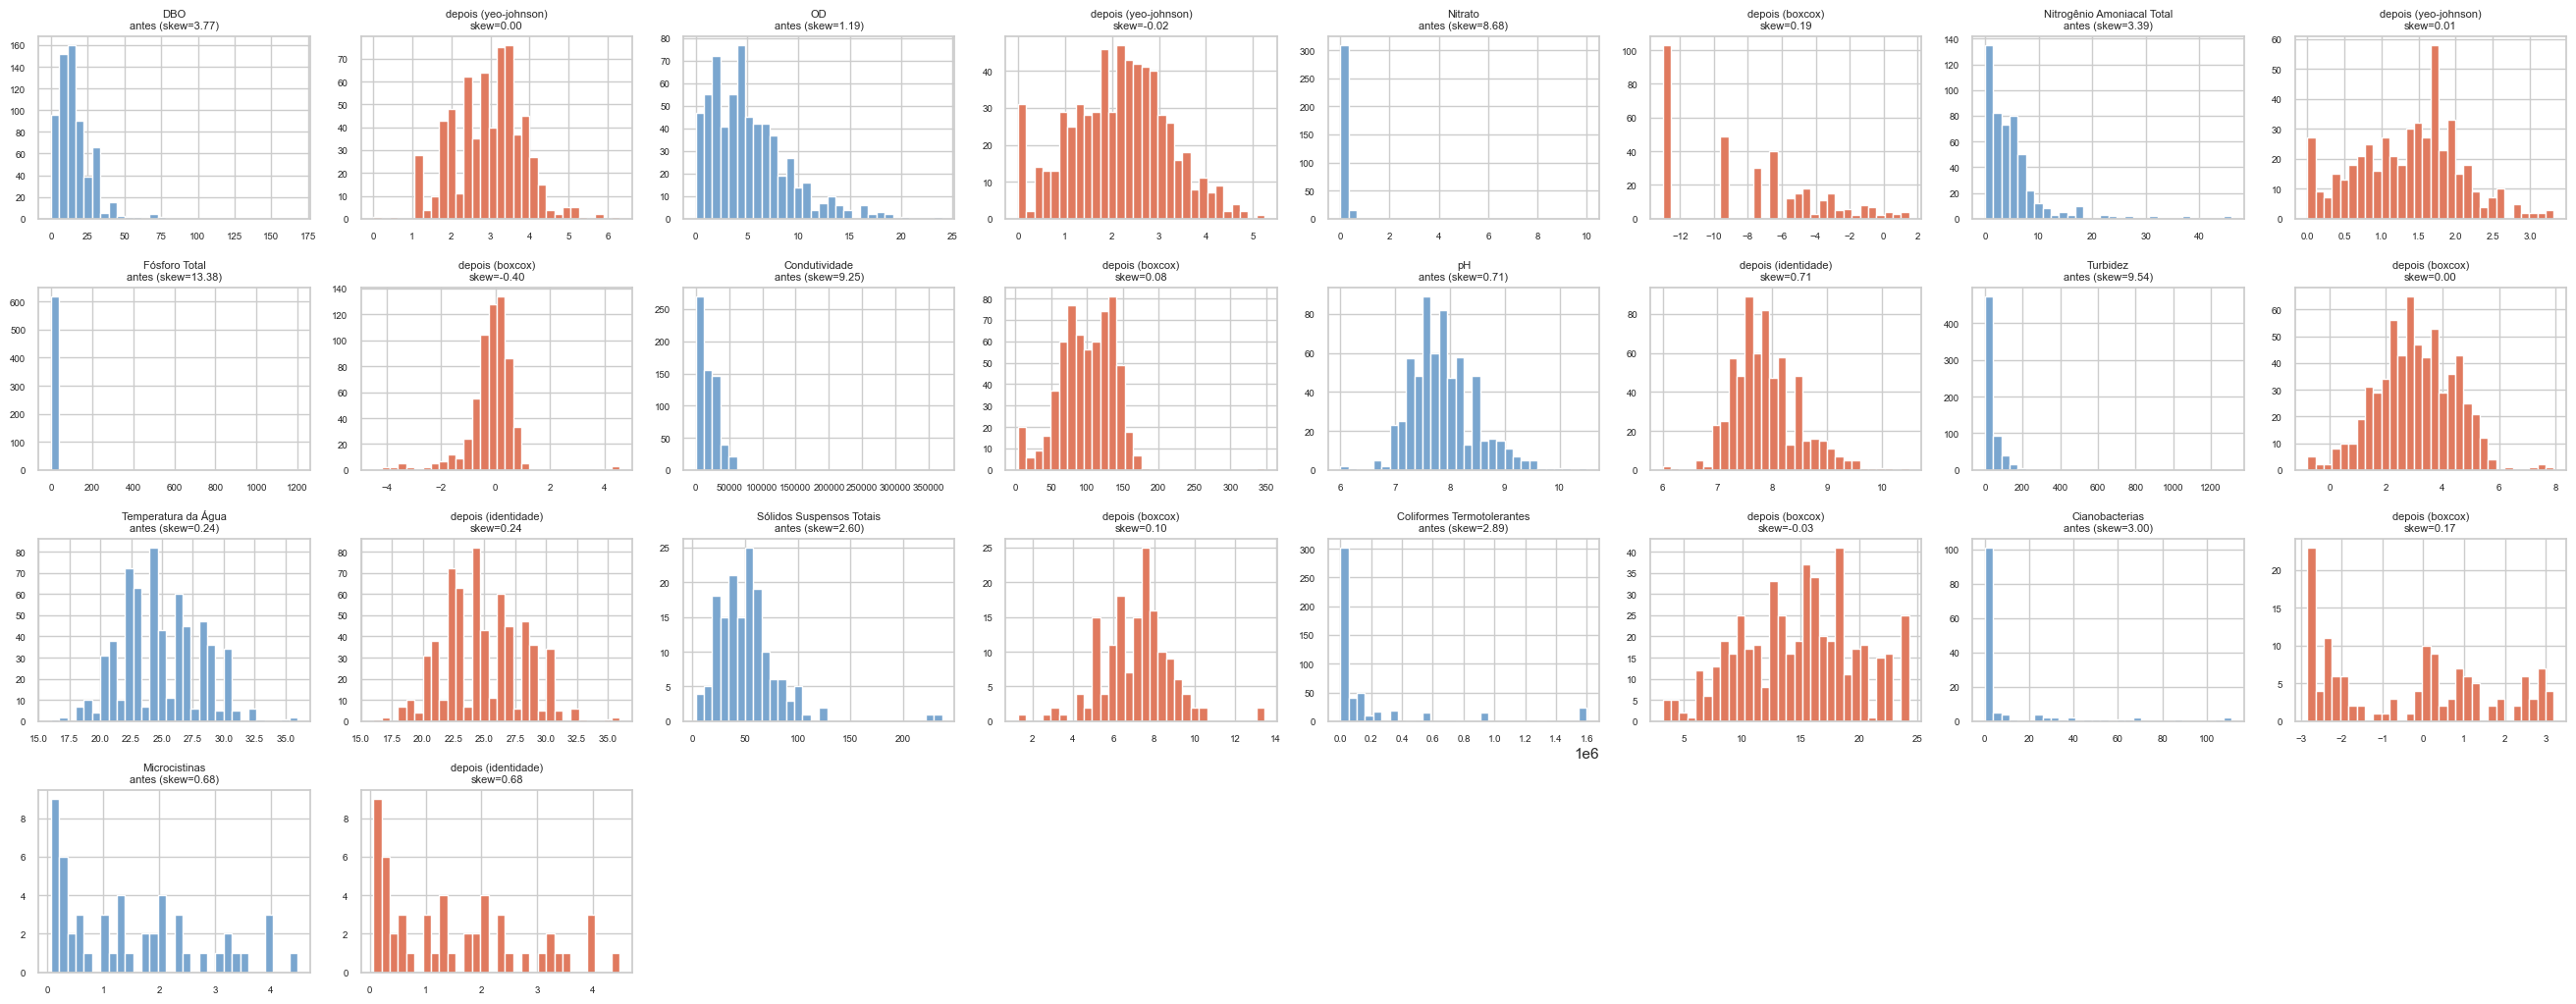

In [5]:
ncols = 4  # 4 pares (8 painéis) por linha
nrows = (len(VARS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols * 2, figsize=(3.3 * ncols * 2, 2.6 * nrows))

for i, v in enumerate(VARS):
    r, c = divmod(i, ncols)
    ax_a = axes[r, c * 2]
    ax_d = axes[r, c * 2 + 1]

    x = df[v].dropna().to_numpy(dtype=float)
    y = pd.Series(df_transf[v]).dropna().to_numpy(dtype=float)

    ax_a.hist(x, bins=30, color="#7aa6cf", edgecolor="white")
    ax_a.set_title(f"{v}\nantes (skew={pd.Series(x).skew():.2f})", fontsize=8)
    ax_a.tick_params(labelsize=7)

    ax_d.hist(y, bins=30, color="#e07a5f", edgecolor="white")
    tipo, _ = transformacoes[v]
    ax_d.set_title(f"depois ({tipo})\nskew={pd.Series(y).skew():.2f}", fontsize=8)
    ax_d.tick_params(labelsize=7)

# Apaga painéis sobressalentes
for j in range(len(VARS), nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c * 2].axis("off")
    axes[r, c * 2 + 1].axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "transf_antes_depois.png", dpi=150)
plt.show()

## Sanidade da inversão

Para cada variável: aplicar `inverter_transformacao` no resultado e comparar com o valor original. **Critério de aceite**: `max |x_inv − x_orig| < 1e-6` em todas as variáveis.

Isso é a precondição para a Etapa 6 conseguir voltar à escala original sem perda numérica.

In [6]:
rev_rows = []
for v in VARS:
    tipo, lmbda = transformacoes[v]
    x_orig = df[v].to_numpy(dtype=float)
    x_rec  = inverter_transformacao(df_transf[v].to_numpy(dtype=float), tipo, lmbda)
    mask = ~np.isnan(x_orig)
    err_max = float(np.max(np.abs(x_orig[mask] - x_rec[mask]))) if mask.any() else 0.0
    rev_rows.append({"variavel": v, "tipo": tipo, "err_max": err_max,
                     "ok": err_max < REVERSIBILIDADE_TOL})

tab_rev = pd.DataFrame(rev_rows).set_index("variavel")
todas_ok = bool(tab_rev["ok"].all())
print(f"Inversão dentro de {REVERSIBILIDADE_TOL}: {todas_ok}")
assert todas_ok, f"Falha de reversibilidade em: {tab_rev[~tab_rev['ok']].index.tolist()}"
tab_rev

Inversão dentro de 1e-06: True


,tipo,err_max,ok
variavel,,,
DBO,yeo-johnson,1.136868e-13,True
OD,yeo-johnson,1.421085e-14,True
Nitrato,boxcox,1.776357e-15,True
Nitrogênio Amoniacal Total,yeo-johnson,4.973799e-14,True
Fósforo Total,boxcox,1.364242e-12,True
Condutividade,boxcox,1.309672e-10,True
pH,identidade,0.000000e+00,True
Turbidez,boxcox,9.094947e-13,True
Temperatura da Água,identidade,0.000000e+00,True


## Persistência

Saídas escritas em `Data/ProcessedData/`:

- `dataset_transformado.parquet` — dataset com as 13 variáveis numéricas em escala transformada (as colunas `_LD`, `Data`, `Ano`, `Codigo Local`, `Local` ficam intactas).
- `transform_params.json` — `{variavel: {tipo, lambda, alerta?}}`, consumido por `06_PostImputation` para inverter.

O parquet preserva NaN; o número de linhas é igual ao do input.

In [7]:
out_parquet = OUT_DIR / "dataset_transformado.parquet"
out_json    = OUT_DIR / "transform_params.json"

df_transf.to_parquet(out_parquet, index=False)
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(transform_params, f, ensure_ascii=False, indent=2)

print(f"Salvo: {out_parquet} ({out_parquet.stat().st_size} bytes)")
print(f"Salvo: {out_json}")
print(f"Linhas: {len(df_transf)} (esperado {len(df)})")
print(f"Colunas: {df_transf.shape[1]}")

Salvo: ..\..\Data\ProcessedData\dataset_transformado.parquet (43370 bytes)
Salvo: ..\..\Data\ProcessedData\transform_params.json
Linhas: 657 (esperado 657)
Colunas: 30


## Síntese final

- 13 variáveis processadas: 3 em identidade, 3 em Yeo-Johnson, 7 em Box-Cox.
- Skewness reduzido a `|skew| < 0,5` em todas as variáveis transformadas exceto **Fósforo Total** (skew ≈ −0,40 mas kurtosis residual = 8,9 — `alerta` registrado em `transform_params.json`).
- Inversão verificada com `max |x_inv − x_orig| < 1e-6` em todas as 13 variáveis.
- Parquet de saída tem o mesmo número de linhas que o input e mantém as colunas auxiliares (`_LD`, `Data`, `Codigo Local`, `Local`, `Ano`) intactas para os próximos notebooks.

### Aviso para a Etapa 6

**Antes** de calcular IQA, comparar com baselines ou apresentar resultados em escala original, é **obrigatório** aplicar `inverter_transformacao` usando os parâmetros de `transform_params.json`. Caso contrário, métricas e gráficos refletirão a escala transformada (não interpretável).

### Próximo notebook

`02_features_temporais.ipynb` — deriva `ano_norm`, `Mes_sin/cos`, `umido` e `dias_desde_inicio` sobre o dataset transformado.